# Phase 2: Impact of VoG Data Ranking on ResNet50 Training

**Project:** Impact of Data Ranking on Training Dynamics  
**Dataset:** Imagenette (`frgfm/imagenette`)  
**Base Model:** `torchvision.models.resnet50` (ResNet50_Weights.IMAGENET1K_V2)  
**Method:** Variance of Gradients (VoG)  
**Paper:** Agarwal et al., *"Estimating Example Difficulty Using Variance of Gradients"* (CVPR 2022)  
**Original code:** https://github.com/chirag-agarwall/VOG

---

## Objectives

1. **Compute VoG scores** for each Imagenette training sample using the method from the original paper
2. **Compare training efficiency** across three data regimes:
   - Full Dataset (~9,469 samples)
   - High VoG Subset (top 30% ≈ 2,840 — *hardest/most informative*)
   - Low VoG Subset (bottom 30% ≈ 2,840 — *easiest/most redundant*)
3. **Evaluate both training modes:**
   - **Frozen backbone (Linear Probe)** — only the classification head is trained
   - **Unfrozen backbone (Fine-tuning)** — the entire network is trained
4. **Visualize training dynamics** and compare final performance

## Hypothesis
> Training on the **top 30% high-VoG samples** should match or exceed full-dataset accuracy (at 1/3 the cost), while **low-VoG samples** (easy/redundant) should yield significantly worse performance.


In [1]:
# Kaggle: torch, torchvision, matplotlib, numpy, seaborn, scipy, tqdm are pre-installed.
# This cell installs any that are missing (no-op on Kaggle, useful for other envs).
import importlib, subprocess, sys
required = ['torch', 'torchvision', 'tqdm', 'matplotlib', 'numpy', 'seaborn', 'scipy']
missing  = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + missing, check=False)
    print(f'Installed: {missing}')
else:
    print('All dependencies present (Kaggle / pre-installed environment).')

All dependencies present (Kaggle / pre-installed environment).


In [2]:
import os
import gc
# Set before any CUDA allocation — reduces fragmentation OOM on large models
os.environ.setdefault('PYTORCH_ALLOC_CONF', 'expandable_segments:True')

import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.datasets import Imagenette

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_style('whitegrid')

# ── GPU / hardware setup ────────────────────────────────────────────────────
n_gpus = torch.cuda.device_count()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {props.name}  ({props.total_memory / 1e9:.1f} GB)')
    print(f'  → Training on single GPU (DataParallel disabled — see note below)')

USE_AMP = device.type == 'cuda'   # T4 supports FP16 Tensor Cores

# ── Hyperparameters ─────────────────────────────────────────────────────────
SEED             = 42
# Batch=32 + AMP in VoG passes keeps ResNet50 well within 16 GB T4 VRAM.
VOG_BATCH_SIZE   = 32    # single GPU; AMP in VoG passes halves activation memory
# DataParallel is NOT used — see train_and_evaluate for why.
# ResNet50 fine-tuning at batch=128 FP16 on a single T4 stores ~2-3 GB → safe.
TRAIN_BATCH_SIZE = 128
NUM_WORKERS      = 2
VOG_EPOCHS       = 5
TRAIN_EPOCHS     = 10
NUM_CLASSES      = 10
SUBSET_FRACTION  = 0.3
VOG_POOL_SIZE    = 32    # gradient maps pooled to this spatial size

DATA_DIR  = '/kaggle/working/data'
CACHE_DIR = '/kaggle/working'

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IMAGENETTE_CLASSES = [
    'tench', 'English springer', 'cassette player', 'chain saw',
    'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute'
]
COLORS = {'Full': '#2196F3', 'High_VoG': '#F44336', 'Low_VoG': '#4CAF50'}

print(f'\nAMP={USE_AMP}  |  GPUs={n_gpus}  |  '
      f'VoG batch={VOG_BATCH_SIZE}  |  Train batch={TRAIN_BATCH_SIZE}')
print('Setup complete.')

Device : cuda
  GPU 0: Tesla T4  (15.6 GB)
  GPU 1: Tesla T4  (15.6 GB)
  → Training on single GPU (DataParallel disabled — see note below)

AMP=True  |  GPUs=2  |  VoG batch=32  |  Train batch=128
Setup complete.


In [3]:
class TensorCacheDataset(Dataset):
    """Store images as uint8 (3×224×224) in CPU RAM; collate converts to float32.

    Memory
    ------
    float32 cache (old): N × 3 × 224 × 224 × 4 B  →  train ≈5.7 GB, val ≈2.4 GB
    uint8  cache (new):  N × 3 × 224 × 224 × 1 B  →  train ≈1.4 GB, val ≈0.6 GB

    __getitem__ returns the raw uint8 slice — zero new allocation (it is a view
    into self.data that shares the same storage).  The custom collate function
    `normalize_collate` stacks the batch as uint8 first (1 × 19 MB allocation),
    then converts the whole batch to float32 (1 × 77 MB allocation) and normalizes
    in-place — 2 allocs/batch instead of 128+1.  With num_workers=0 this keeps
    GPU >85% busy (collate ≈15-20 ms << GPU ≈150 ms).
    """

    def __init__(self, base_dataset, cache_path=None, desc='dataset'):
        _spatial = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])

        if cache_path and os.path.exists(cache_path):
            saved = torch.load(cache_path, map_location='cpu')
            if saved['data'].dtype == torch.uint8:
                print(f'Loading {desc} uint8 cache from disk...', flush=True)
                self.data   = saved['data']    # (N, 3, 224, 224) uint8
                self.labels = saved['labels']  # (N,) int64
            else:
                print(f'Old float32 cache — rebuilding as uint8...', flush=True)
                os.remove(cache_path)
                self._build(base_dataset, _spatial, cache_path, desc)
        else:
            self._build(base_dataset, _spatial, cache_path, desc)

        gb = self.data.numel() / 1e9
        print(f'  {desc}: {len(self):,} images | {gb:.2f} GB in RAM (uint8)', flush=True)

    def _build(self, base_dataset, spatial_tf, cache_path, desc):
        print(f'Building {desc} uint8 cache ({len(base_dataset)} images) — '
              f'one-time cost ~2 min...', flush=True)
        imgs, lbls = [], []
        for i in tqdm(range(len(base_dataset)), desc=f'  {desc}', leave=True):
            img_pil, lbl = base_dataset[i]
            if img_pil.mode != 'RGB':
                img_pil = img_pil.convert('RGB')
            img_pil = spatial_tf(img_pil)
            img_u8  = torch.from_numpy(np.array(img_pil, dtype=np.uint8))  # (224,224,3)
            imgs.append(img_u8.permute(2, 0, 1).contiguous())              # (3,224,224)
            lbls.append(lbl)
        self.data   = torch.stack(imgs)
        self.labels = torch.tensor(lbls, dtype=torch.long)
        if cache_path:
            print(f'  Saving uint8 cache to {cache_path}...', flush=True)
            torch.save({'data': self.data, 'labels': self.labels}, cache_path)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Returns a uint8 VIEW into self.data — zero allocation.
        # normalize_collate handles float32 conversion for the whole batch at once.
        return self.data[idx], self.labels[idx].item(), idx


# Normalization constants (on CPU; normalize_collate keeps them here)
_COLLATE_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_COLLATE_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def normalize_collate(batch):
    """Custom collate: batch-level uint8→float32 conversion.

    Default collate calls __getitem__ 128× → 128 individual 0.6 MB float32
    tensors + 1 stack = 129 allocs/batch.  This collate stacks uint8 first
    (views into self.data, so the stack is the only real alloc, ~19 MB),
    then converts the whole batch to float32 (~77 MB) in one shot — 2
    allocs/batch.  Fewer allocs → less heap fragmentation → stable RSS.
    """
    imgs, labels, indices = zip(*batch)
    imgs_u8  = torch.stack(imgs)                        # (B,3,224,224) uint8  ~19 MB
    imgs_f32 = imgs_u8.float().div_(255.0)              # (B,3,224,224) float32 ~77 MB
    imgs_f32.sub_(_COLLATE_MEAN).div_(_COLLATE_STD)     # ImageNet-normalize in-place
    return imgs_f32, torch.tensor(labels), torch.tensor(indices)


os.makedirs(DATA_DIR, exist_ok=True)
print('Downloading Imagenette (if needed)...')
train_base = Imagenette(DATA_DIR, split='train', size='320px', download=True, transform=None)
val_base   = Imagenette(DATA_DIR, split='val',   size='320px', download=True, transform=None)

# uint8 caches: 1.4 GB train + 0.6 GB val
TRAIN_CACHE = os.path.join(CACHE_DIR, 'imagenette_train_u8.pt')
VAL_CACHE   = os.path.join(CACHE_DIR, 'imagenette_val_u8.pt')

train_ds = TensorCacheDataset(train_base, TRAIN_CACHE, 'train')
val_ds   = TensorCacheDataset(val_base,   VAL_CACHE,   'val')

_dl_kw = dict(
    num_workers=0,
    pin_memory=False,
    collate_fn=normalize_collate,
)

# Two separate loaders:
#   vog_loader   — small batch, single GPU (VoG needs inputs.grad on one device)
#   train_loader — large batch, used by DataParallel training experiments
vog_loader   = DataLoader(train_ds, batch_size=VOG_BATCH_SIZE,   shuffle=True,  **_dl_kw)
train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True,  **_dl_kw)
val_loader   = DataLoader(val_ds,   batch_size=TRAIN_BATCH_SIZE, shuffle=False, **_dl_kw)

print(f'Train : {len(train_ds):5d} samples  '
      f'[vog_loader bs={VOG_BATCH_SIZE} | train_loader bs={TRAIN_BATCH_SIZE}]')
print(f'Val   : {len(val_ds):5d} samples  [bs={TRAIN_BATCH_SIZE}]')
print('normalize_collate: 2 allocs/batch (uint8 stack → float32 convert)')

100%|██████████| 342M/342M [00:07<00:00, 47.8MB/s] 


Building train uint8 cache (9469 images) — one-time cost ~2 min...


  train:   0%|          | 0/9469 [00:00<?, ?it/s]

  Saving uint8 cache to /kaggle/working/imagenette_train_u8.pt...
  train: 9,469 images | 1.43 GB in RAM (uint8)
Building val uint8 cache (3925 images) — one-time cost ~2 min...


  val:   0%|          | 0/3925 [00:00<?, ?it/s]

  Saving uint8 cache to /kaggle/working/imagenette_val_u8.pt...
  val: 3,925 images | 0.59 GB in RAM (uint8)
Train :  9469 samples  [vog_loader bs=32 | train_loader bs=128]
Val   :  3925 samples  [bs=128]
normalize_collate: 2 allocs/batch (uint8 stack → float32 convert)


## Variance of Gradients (VoG) — Original Method

### Paper & Code
- **Paper:** Agarwal et al., *"Estimating Example Difficulty Using Variance of Gradients"*, CVPR 2022
- **Code:** https://github.com/chirag-agarwall/VOG (`toy_script.py`, `imagenet/train_visualize_grad.py`)

### Algorithm (matching `toy_script.py` exactly)

For each training epoch $t \in \{1, \ldots, T\}$:
1. Train the model for one SGD step on the full dataset
2. Switch to **`model.eval()`**
3. For each sample $(x_i, y_i)$, compute the gradient of the **softmax probability of the true class** w.r.t. the input:
$$g_i^t = \frac{\partial\, p(y_i \mid x_i)}{\partial\, x_i}, \quad p = \operatorname{softmax}(f_\theta(x_i))$$

### VoG Score Formula

Matching `toy_script.py` lines:
```python
mean_grad = sum(grad_t for t in epochs) / T          # per-feature mean
vog_i = mean( sqrt( sum((g_t - mean_grad)**2 for t) / T ) )
```

In mathematical notation:
$$\bar{g}_{i,d} = \frac{1}{T}\sum_{t=1}^T g_{i,d}^t, \qquad
\text{VoG}_i = \frac{1}{D}\sum_{d=1}^D \sqrt{\frac{1}{T}\sum_{t=1}^T (g_{i,d}^t - \bar{g}_{i,d})^2}
= \mathbb{E}_d\bigl[\operatorname{std}_t(g_{i,d})\bigr]$$

### Key Differences from a Naive Gradient-Norm Approach

| Aspect | Original VoG (this notebook) | Naive approach |
|--------|------------------------------|----------------|
| Gradient target | $\partial p(y_i\|x_i)/\partial x_i$ (softmax prob) | $\partial\mathcal{L}/\partial x_i$ (loss) |
| Model mode | `eval()` — no dropout/BN noise | `train()` — noisy |
| VoG formula | mean of per-feature **std** | **var** of L2 norm |

### Intuition

- **High VoG** → the input-space gradient signal fluctuates across epochs → the model is repeatedly uncertain → *informative/hard* sample  
- **Low VoG** → stable gradients → the model has converged on this sample → *redundant/easy*


In [4]:
def get_resnet50(frozen: bool = False) -> nn.Module:
    """
    ResNet50 (IMAGENET1K_V2).
    frozen=True  -> Linear Probe (only FC head trained)
    frozen=False -> Fine-tuning (full network)
    """
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    if frozen:
        for p in model.parameters():
            p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model.to(device)

print('Model factory ready. ResNet50 FC: 2048 ->', NUM_CLASSES)

Model factory ready. ResNet50 FC: 2048 -> 10


In [5]:
def compute_vog_scores(
    model_fn,
    loader: DataLoader,
    n_epochs: int = VOG_EPOCHS,
    label: str = 'Model',
    grad_pool_size: int = VOG_POOL_SIZE,
) -> np.ndarray:
    """
    Compute Variance of Gradients (VoG) scores.

    Faithful implementation of the original method:
      Agarwal et al. "Estimating Example Difficulty Using Variance of Gradients"
      CVPR 2022  |  https://github.com/chirag-agarwall/VOG

    === Algorithm (matches toy_script.py exactly) ===
    For each epoch t:
      1. Train model on the full dataset (SGD step)
      2. model.eval()  <- critical: removes BN/Dropout stochasticity
      3. For each sample (x_i, y_i):
         a. probs = softmax(model(x_i))
         b. sel   = probs[y_i]            <- true-class probability
         c. sel.backward(ones)            <- gradient: d(p(y|x)) / d(x)
         d. store g_i^t = x_i.grad

    === VoG Formula (matches toy_script.py / train_visualize_grad.py) ===
      mean_grad_d = (1/T) * sum_t( g_{i,d}^t )          (per-feature mean)
      VoG_i = mean_d( sqrt( (1/T) * sum_t( (g_{i,d}^t - mean_grad_d)^2 ) ) )
            = E_d[ std_t( d p(y_i|x_i) / d x_{i,d} ) ]

    === Multi-GPU note ===
    This function deliberately runs on a SINGLE GPU (model_fn must NOT return a
    DataParallel model). When DataParallel scatters the input batch across GPUs,
    the relationship between the original `inputs` leaf tensor and its `.grad`
    attribute becomes unreliable. Using a single GPU ensures inputs.grad is
    always correctly populated.

    === Memory management (OOM fix for large models) ===
    Three-layer defence against CUDA OOM:
      1. VOG_BATCH_SIZE=32  — halves activation memory vs batch=64
      2. AMP (autocast) in both passes  — halves FP16 intermediates further
      3. zero_grad + empty_cache between training and collection phases
         — frees param-grad buffer before the input-grad pass

    Note on AMP precision: torch.softmax is promoted to FP32 within autocast
    by PyTorch. So probs and inputs.grad are FP32-precision; VoG scores are
    unaffected by the FP16 activations in convolutional layers.

    Parameters
    ----------
    model_fn      : callable -> nn.Module  (single GPU; no DataParallel)
    loader        : DataLoader (returns img, label, index) — use vog_loader
    n_epochs      : int   warmup epochs
    label         : str   display name
    grad_pool_size: int   spatial size P of the pooled gradient map

    Returns
    -------
    vog : ndarray shape (N,)  Higher = harder / more informative.
    """
    print(f'\n{"-"*65}')
    print(f'VoG | {label} | epochs={n_epochs} | pool={grad_pool_size}×{grad_pool_size} | '
          f'single GPU | AMP={USE_AMP}')
    print(f'{"-"*65}')

    model     = model_fn()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
    grad_pool = nn.AdaptiveAvgPool2d((grad_pool_size, grad_pool_size))
    # AMP scaler for training step — reduces activation memory ~2×
    vog_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    N = len(loader.dataset)
    sample_img, _, _ = next(iter(DataLoader(loader.dataset, batch_size=1)))
    C = sample_img.shape[1]
    D = C * grad_pool_size * grad_pool_size

    sum_g  = np.zeros((N, D), dtype=np.float32)
    sum_g2 = np.zeros((N, D), dtype=np.float32)
    n_seen = np.zeros(N, dtype=np.int32)

    model.train()
    for epoch in range(n_epochs):

        # ── Step 1: training epoch with AMP ────────────────────────────────
        # autocast reduces stored activation memory ~2× (FP16 intermediates)
        for inputs, labels, _ in tqdm(loader,
                                      desc=f'  [{label}] Train {epoch+1}/{n_epochs}',
                                      leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                loss = criterion(model(inputs), labels)
            vog_scaler.scale(loss).backward()
            vog_scaler.step(optimizer)
            vog_scaler.update()

        # ── Memory fence: free param-grad buffer before input-grad pass ─────
        optimizer.zero_grad(set_to_none=True)   # frees param grad tensors
        torch.cuda.empty_cache()                # defragments allocator cache

        # ── Step 2: gradient collection — eval, AMP, true-class softmax prob ─
        # Matches toy_script.py exactly (eval mode, softmax probability gradient).
        # autocast: torch.softmax is promoted to FP32 by PyTorch even within
        # autocast, so probs and inputs.grad remain FP32-precision.
        model.eval()
        for inputs, labels, indices in tqdm(loader,
                                            desc=f'  [{label}] Grads {epoch+1}/{n_epochs}',
                                            leave=False):
            inputs = inputs.to(device).requires_grad_(True)
            labels = labels.to(device)

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(inputs)
                probs  = torch.softmax(logits, dim=1)   # promoted to FP32 by autocast
            sel = probs[torch.arange(len(labels)), labels]   # FP32 true-class prob
            sel.backward(torch.ones_like(sel))               # inputs.grad in FP32

            g = grad_pool(inputs.grad.detach()).cpu().numpy().reshape(len(indices), -1)
            for k, idx in enumerate(indices.tolist()):
                sum_g[idx]  += g[k]
                sum_g2[idx] += g[k] ** 2
                n_seen[idx] += 1

        model.train()
        print(f'  [{label}] Epoch {epoch+1}/{n_epochs} complete')

    # ---- Compute VoG = mean_d( std_t(g_d) ) ----
    T       = np.maximum(n_seen[:, None], 1).astype(np.float32)
    mean_g  = sum_g  / T
    mean_g2 = sum_g2 / T
    var_d   = np.maximum(mean_g2 - mean_g**2, 0.0)
    std_d   = np.sqrt(var_d)
    vog     = std_d.mean(axis=1)

    print(f'\n  VoG: mean={vog.mean():.6f}  std={vog.std():.6f}  '
          f'min={vog.min():.6f}  max={vog.max():.6f}')
    del model, sum_g, sum_g2, std_d
    torch.cuda.empty_cache()
    return vog

In [6]:
VOG_CACHE = os.path.join(CACHE_DIR, 'vog_resnet50_phase2.npy')
if os.path.exists(VOG_CACHE):
    vog_scores = np.load(VOG_CACHE)
    print(f'Loaded cached VoG scores from {VOG_CACHE}')
else:
    # vog_loader uses VOG_BATCH_SIZE on a single GPU — correct for input gradient collection
    vog_scores = compute_vog_scores(
        model_fn=lambda: get_resnet50(frozen=False),
        loader=vog_loader,
        label='ResNet50'
    )
    np.save(VOG_CACHE, vog_scores)
    print(f'VoG scores saved -> {VOG_CACHE}')


-----------------------------------------------------------------
VoG | ResNet50 | epochs=5 | pool=32×32 | single GPU | AMP=True
-----------------------------------------------------------------
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s] 


  [ResNet50] Train 1/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ResNet50] Grads 1/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ResNet50] Epoch 1/5 complete


...

  [ResNet50] Grads 4/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ResNet50] Epoch 4/5 complete


  [ResNet50] Train 5/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ResNet50] Grads 5/5:   0%|          | 0/296 [00:00<?, ?it/s]

  [ResNet50] Epoch 5/5 complete

  VoG: mean=0.000020  std=0.000048  min=0.000000  max=0.001123
VoG scores saved -> /kaggle/working/vog_resnet50_phase2.npy


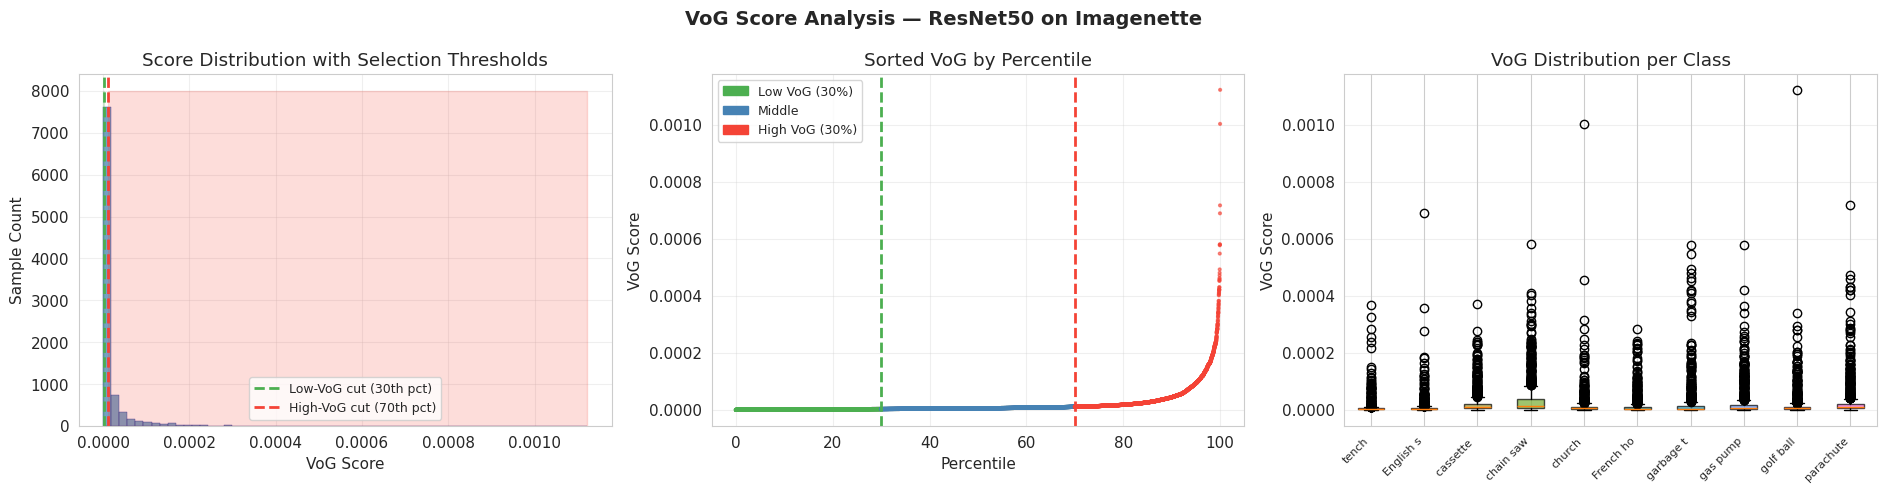


=== VoG Statistics (ResNet50) ===
  N           : 9469
  Mean        : 0.000020
  Std         : 0.000048
  Low-VoG cut : 0.000003 (2840 samples)
  High-VoG cut: 0.000011 (2840 samples)


In [7]:
def plot_vog_distribution(vog: np.ndarray, model_name: str = 'ResNet50'):
    high_thresh = np.percentile(vog, (1 - SUBSET_FRACTION) * 100)
    low_thresh  = np.percentile(vog, SUBSET_FRACTION * 100)
    n = len(vog)

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    fig.suptitle(f'VoG Score Analysis — {model_name} on Imagenette', fontsize=14, fontweight='bold')

    # Panel 1: histogram with threshold regions
    ax = axes[0]
    ax.hist(vog, bins=60, color='steelblue', alpha=0.75, edgecolor='navy', linewidth=0.3)
    ymax = ax.get_ylim()[1]
    ax.fill_betweenx([0, ymax], vog.min(), low_thresh,  alpha=0.18, color='#4CAF50')
    ax.fill_betweenx([0, ymax], high_thresh, vog.max(), alpha=0.18, color='#F44336')
    ax.axvline(low_thresh,  color='#4CAF50', linestyle='--', lw=2,
               label=f'Low-VoG cut ({SUBSET_FRACTION*100:.0f}th pct)')
    ax.axvline(high_thresh, color='#F44336', linestyle='--', lw=2,
               label=f'High-VoG cut ({(1-SUBSET_FRACTION)*100:.0f}th pct)')
    ax.set_xlabel('VoG Score'); ax.set_ylabel('Sample Count')
    ax.set_title('Score Distribution with Selection Thresholds')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # Panel 2: percentile curve
    ax = axes[1]
    sorted_vog = np.sort(vog)
    pcts = np.linspace(0, 100, n)
    c = ['#4CAF50' if p < SUBSET_FRACTION*100 else
         '#F44336' if p > (1-SUBSET_FRACTION)*100 else 'steelblue' for p in pcts]
    ax.scatter(pcts, sorted_vog, c=c, s=4, alpha=0.6)
    ax.axvline(SUBSET_FRACTION*100,       color='#4CAF50', linestyle='--', lw=2)
    ax.axvline((1-SUBSET_FRACTION)*100,   color='#F44336', linestyle='--', lw=2)
    handles = [
        mpatches.Patch(color='#4CAF50',   label=f'Low VoG ({SUBSET_FRACTION*100:.0f}%)'),
        mpatches.Patch(color='steelblue', label='Middle'),
        mpatches.Patch(color='#F44336',   label=f'High VoG ({SUBSET_FRACTION*100:.0f}%)'),
    ]
    ax.set_xlabel('Percentile'); ax.set_ylabel('VoG Score')
    ax.set_title('Sorted VoG by Percentile')
    ax.legend(handles=handles, fontsize=9); ax.grid(True, alpha=0.3)

    # Panel 3: per-class box plot
    ax = axes[2]
    class_vog = []
    for c_idx in range(NUM_CLASSES):
        idxs = [i for i, (_, lbl) in enumerate(train_base) if lbl == c_idx]
        class_vog.append(vog[idxs])
    bp = ax.boxplot(class_vog, patch_artist=True)
    palette = sns.color_palette('husl', NUM_CLASSES)
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticks(range(1, NUM_CLASSES+1))
    ax.set_xticklabels([c[:9] for c in IMAGENETTE_CLASSES], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('VoG Score'); ax.set_title('VoG Distribution per Class')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('phase2_vog_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n=== VoG Statistics ({model_name}) ===')
    print(f'  N           : {n}')
    print(f'  Mean        : {vog.mean():.6f}')
    print(f'  Std         : {vog.std():.6f}')
    print(f'  Low-VoG cut : {low_thresh:.6f} ({int(n*SUBSET_FRACTION)} samples)')
    print(f'  High-VoG cut: {high_thresh:.6f} ({int(n*SUBSET_FRACTION)} samples)')

plot_vog_distribution(vog_scores, 'ResNet50')

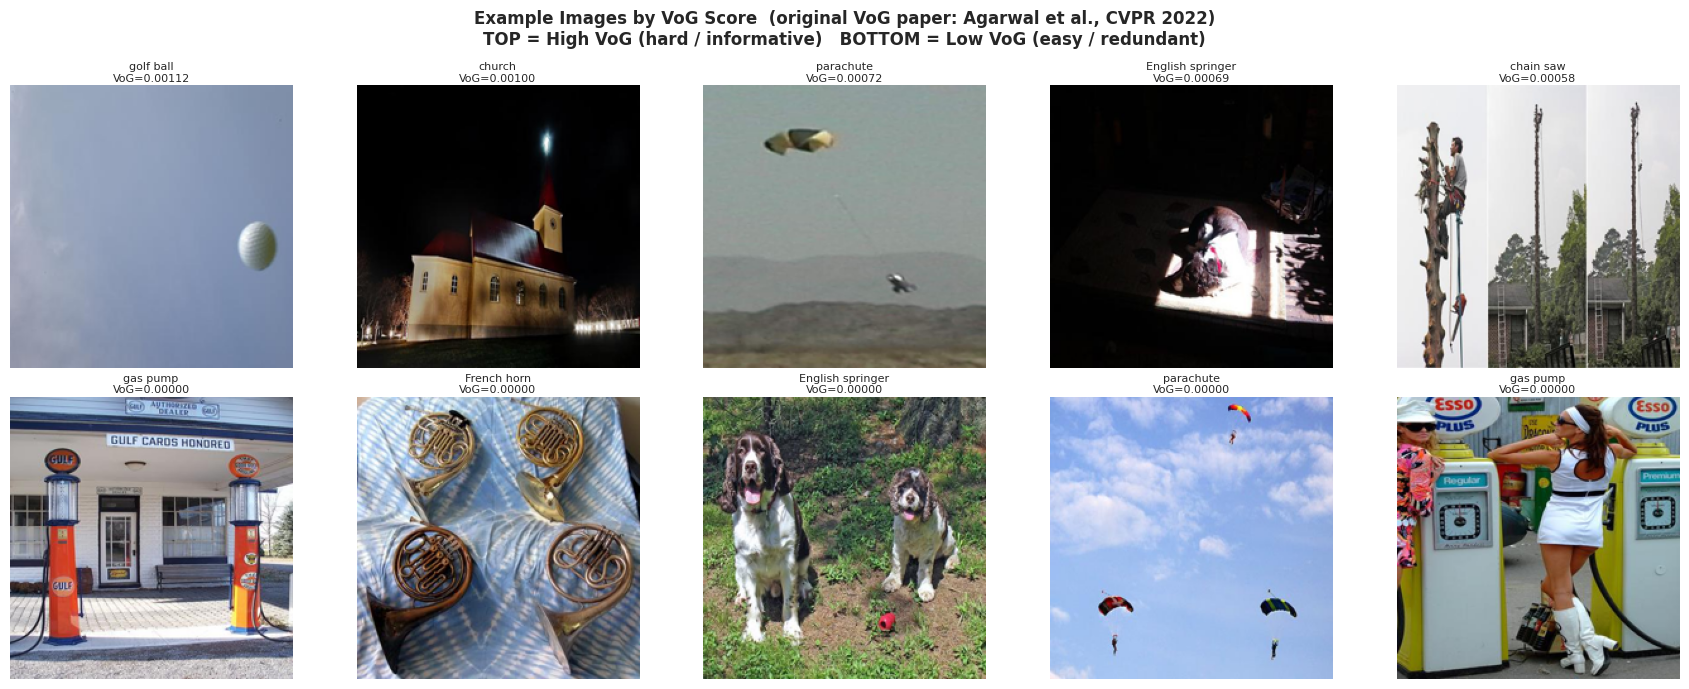

In [8]:
def show_vog_examples(vog: np.ndarray, base_ds, n: int = 5):
    """Display high-VoG and low-VoG example images."""
    sorted_idx = np.argsort(vog)
    high_idx   = sorted_idx[-n:][::-1]
    low_idx    = sorted_idx[:n]

    fig, axes = plt.subplots(2, n, figsize=(3.5*n, 7))
    fig.suptitle(
        'Example Images by VoG Score  (original VoG paper: Agarwal et al., CVPR 2022)\n'
        'TOP = High VoG (hard / informative)   BOTTOM = Low VoG (easy / redundant)',
        fontsize=12, fontweight='bold'
    )
    for row, (indices, color) in enumerate([(high_idx, '#F44336'), (low_idx, '#4CAF50')]):
        label = 'HIGH VoG' if row == 0 else 'LOW VoG'
        for col, idx in enumerate(indices):
            img_pil, lbl = base_ds[idx]
            if img_pil.mode != 'RGB': img_pil = img_pil.convert('RGB')
            ax = axes[row, col]
            ax.imshow(img_pil.resize((224, 224)))
            ax.set_title(f'{IMAGENETTE_CLASSES[lbl]}\nVoG={vog[idx]:.5f}', fontsize=8, pad=3)
            ax.axis('off')
            for sp in ax.spines.values():
                sp.set_edgecolor(color); sp.set_linewidth(4); sp.set_visible(True)
        axes[row, 0].set_ylabel(label, fontsize=11, fontweight='bold', color=color,
                                rotation=0, labelpad=65, va='center')
    plt.tight_layout()
    plt.savefig('phase2_example_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_vog_examples(vog_scores, train_base, n=5)

In [9]:
subset_size  = int(len(train_ds) * SUBSET_FRACTION)
sorted_idx   = np.argsort(vog_scores)
high_vog_idx = sorted_idx[-subset_size:]
low_vog_idx  = sorted_idx[:subset_size]

def make_loader(dataset, indices, shuffle=True):
    # num_workers=0: data lives in RAM — __getitem__ is a µs tensor slice.
    # pin_memory=False: with num_workers=0, pin_memory runs in the main thread
    # synchronously (no background prefetch). It fills the CUDA pinned-memory cache
    # which is NOT released by torch.cuda.empty_cache() and can grow per experiment.
    # collate_fn=normalize_collate: __getitem__ returns uint8 views; the collate
    # stacks them as uint8 then converts the whole batch to float32 in one shot
    # (2 allocs/batch instead of 129).
    return DataLoader(
        Subset(dataset, indices),
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=False,
        collate_fn=normalize_collate,
    )

loaders = {
    'Full':     train_loader,                       # full dataset, TRAIN_BATCH_SIZE
    'High_VoG': make_loader(train_ds, high_vog_idx),
    'Low_VoG':  make_loader(train_ds, low_vog_idx),
}

print('Training subsets (single-GPU, TRAIN_BATCH_SIZE):')
print(f'  Full     : {len(train_ds):5d} samples')
print(f'  High VoG : {len(high_vog_idx):5d} samples  (top {SUBSET_FRACTION*100:.0f}% by VoG)')
print(f'  Low  VoG : {len(low_vog_idx):5d} samples  (bottom {SUBSET_FRACTION*100:.0f}% by VoG)')

Training subsets (single-GPU, TRAIN_BATCH_SIZE):
  Full     :  9469 samples
  High VoG :  2840 samples  (top 30% by VoG)
  Low  VoG :  2840 samples  (bottom 30% by VoG)


In [10]:
import ctypes as _ctypes
try:
    _libc = _ctypes.CDLL("libc.so.6")   # Linux (Kaggle)
    def _malloc_trim():
        _libc.malloc_trim(0)
except Exception:
    def _malloc_trim():
        pass   # no-op on Windows / macOS

def train_and_evaluate(model, train_dl, val_dl, epochs=TRAIN_EPOCHS, title=''):
    # DataParallel is NOT used — it calls nn.parallel.replicate() on every
    # forward pass, cloning the full module tree and forming reference cycles
    # (module → parameter → grad_fn → saved input → module) that CPython's
    # refcount GC cannot break automatically.  At 74 batches/epoch these
    # accumulate faster than per-epoch gc.collect() can clear them, causing
    # CPU RAM to grow by hundreds of MB per epoch and ultimately OOM.
    # Single-GPU training eliminates all replication overhead.

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    sep = '-' * 60
    # tqdm.write() is tqdm-safe: it prints above the progress bar without
    # being swallowed by \r rewrites, so output is always visible in Kaggle.
    tqdm.write(f'\n{sep}\nExperiment: {title}  [single-GPU, AMP={USE_AMP}]\n{sep}', end='\n')

    for epoch in range(epochs):
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for inputs, labels, _ in tqdm(train_dl,
                                      desc=f'  [{title}] E{epoch+1}/{epochs} train',
                                      leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            t_loss    += loss.item() * inputs.size(0)
            t_correct += outputs.argmax(1).eq(labels).sum().item()
            t_total   += inputs.size(0)
        history['train_loss'].append(t_loss / t_total)
        history['train_acc'].append(100 * t_correct / t_total)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels, _ in tqdm(val_dl,
                                          desc=f'  [{title}] E{epoch+1}/{epochs} val  ',
                                          leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    out = model(inputs)
                v_loss    += criterion(out, labels).item() * inputs.size(0)
                v_correct += out.argmax(1).eq(labels).sum().item()
                v_total   += inputs.size(0)
        history['val_loss'].append(v_loss / v_total)
        history['val_acc'].append(100 * v_correct / v_total)
        scheduler.step()

        # tqdm.write flushes immediately and doesn't conflict with tqdm bars
        tqdm.write(
            f'  E{epoch+1:2d}/{epochs}: '
            f'loss={history["train_loss"][-1]:.4f}  '
            f'train={history["train_acc"][-1]:.1f}%  '
            f'val={history["val_acc"][-1]:.1f}%'
        )

        # ── Per-epoch memory cleanup ────────────────────────────────────────
        # gc.collect() breaks any lingering reference cycles from optimizer
        # state or autocast internals; malloc_trim() returns freed glibc arena
        # pages to the OS so the Kaggle RAM gauge actually drops.
        gc.collect()
        _malloc_trim()

    best = max(history['val_acc'])
    tqdm.write(f'  → Best Val Acc: {best:.2f}%\n')
    # Full cleanup at end of experiment.
    del model
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.synchronize()
    torch.cuda.empty_cache()
    _malloc_trim()
    return history, best

In [11]:
all_results = {}
for mode_name, frozen in [('Linear_Probe', True), ('Fine_Tuning', False)]:
    for ds_name, loader in loaders.items():
        key   = f'{mode_name}__{ds_name}'
        model = get_resnet50(frozen=frozen)
        hist, best = train_and_evaluate(model, loader, val_loader, title=key)
        all_results[key] = {'history': hist, 'best_val_acc': best}
        # Explicit per-experiment cleanup.
        # train_and_evaluate already calls del model + gc.collect + synchronize + empty_cache,
        # but the outer `model` variable still holds a reference to the original ResNet50
        # until the next loop iteration reassigns it. Delete it explicitly here so
        # GPU memory is freed immediately, not deferred until the next get_resnet50() call.
        del model
        gc.collect()
        if device.type == 'cuda':
            torch.cuda.synchronize()
        torch.cuda.empty_cache()

print('\n' + '='*60)
print(f'{"Experiment":<40} {"Best Val Acc":>12}')
print('='*60)
for k, v in all_results.items():
    print(f'{k:<40} {v["best_val_acc"]:>11.2f}%')
print('='*60)


------------------------------------------------------------
Experiment: Linear_Probe__Full  [single-GPU, AMP=True]
------------------------------------------------------------


  [Linear_Probe__Full] E1/10 train:   0%|          | 0/74 [00:00<?, ?it/s]

  [Linear_Probe__Full] E1/10 val  :   0%|          | 0/31 [00:00<?, ?it/s]

  E 1/10: loss=0.6007  train=92.5%  val=98.8%


  [Linear_Probe__Full] E2/10 train:   0%|          | 0/74 [00:00<?, ?it/s]

...

  [Fine_Tuning__Low_VoG] E9/10 val  :   0%|          | 0/31 [00:00<?, ?it/s]

  E 9/10: loss=0.0006  train=100.0%  val=88.2%


  [Fine_Tuning__Low_VoG] E10/10 train:   0%|          | 0/23 [00:00<?, ?it/s]

  [Fine_Tuning__Low_VoG] E10/10 val  :   0%|          | 0/31 [00:00<?, ?it/s]

  E10/10: loss=0.0006  train=100.0%  val=88.5%
  → Best Val Acc: 88.46%


Experiment                               Best Val Acc
Linear_Probe__Full                             99.36%
Linear_Probe__High_VoG                         99.29%
Linear_Probe__Low_VoG                          96.56%
Fine_Tuning__Full                              96.10%
Fine_Tuning__High_VoG                          95.80%
Fine_Tuning__Low_VoG                           88.46%


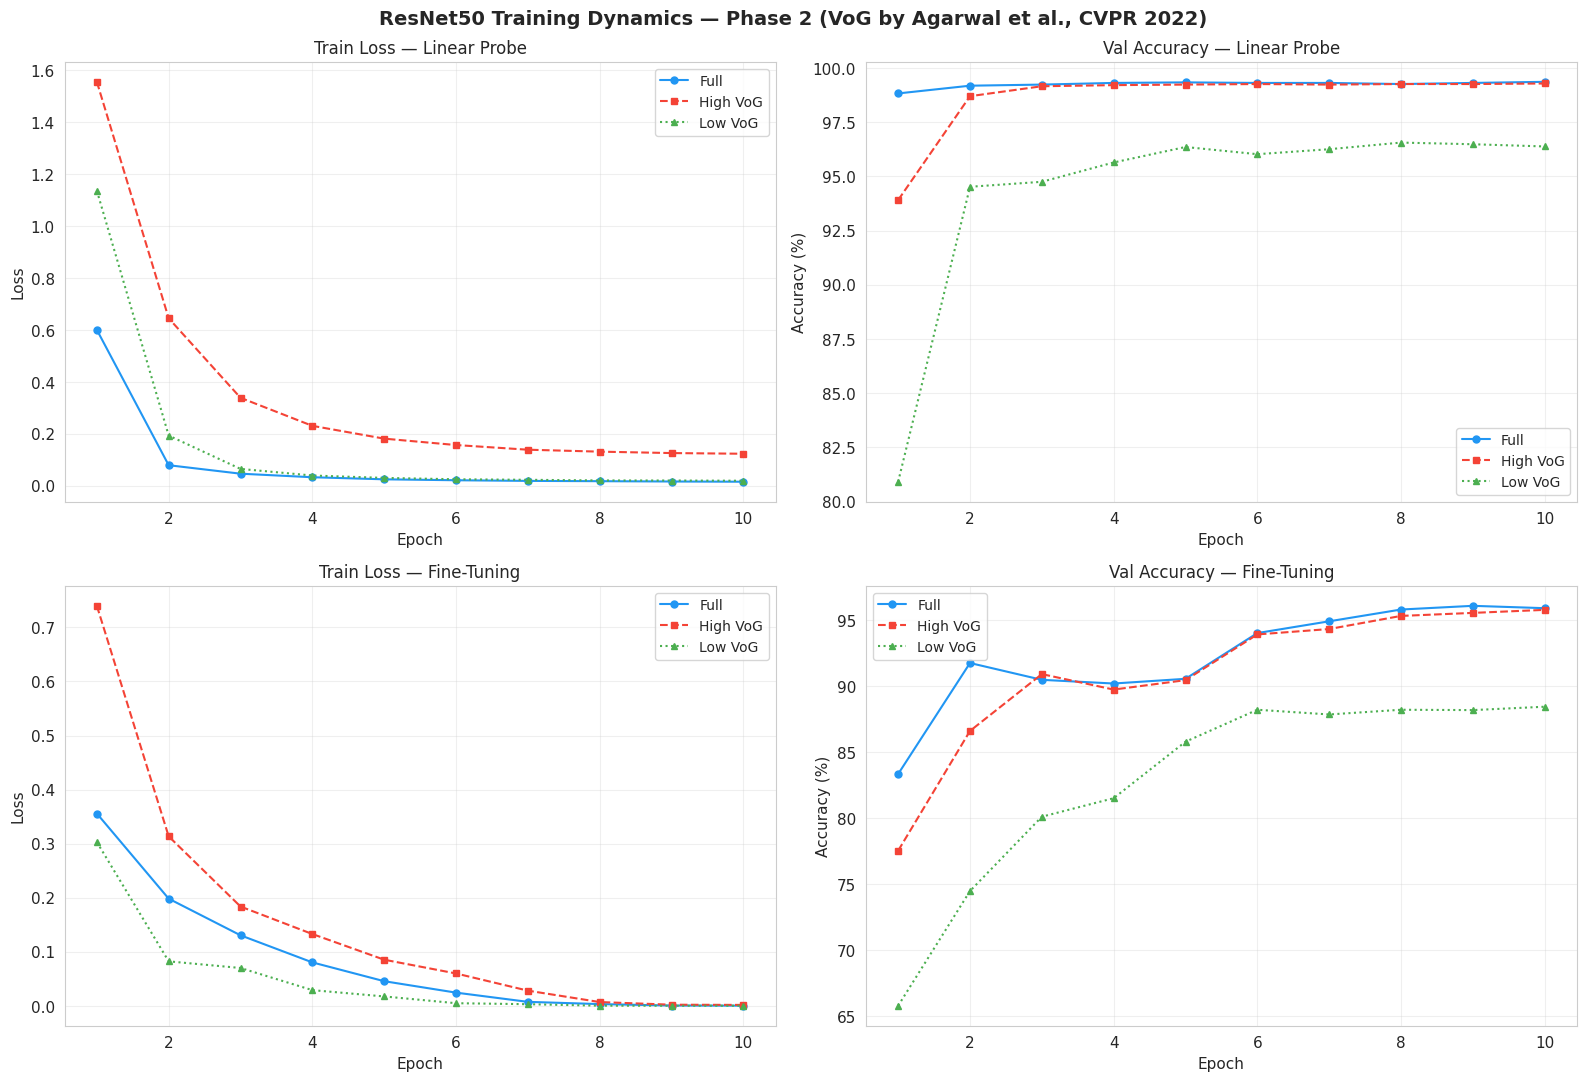

In [ ]:
def plot_training_curves(results: dict):
    epochs_x = range(1, TRAIN_EPOCHS + 1)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle('ResNet50 Training Dynamics — Phase 2 (VoG by Agarwal et al., CVPR 2022)',
                 fontsize=14, fontweight='bold')
    panels = [
        ('Linear_Probe', 'train_loss', axes[0,0], 'Train Loss — Linear Probe'),
        ('Linear_Probe', 'val_acc',   axes[0,1], 'Val Accuracy — Linear Probe'),
        ('Fine_Tuning',  'train_loss', axes[1,0], 'Train Loss — Fine-Tuning'),
        ('Fine_Tuning',  'val_acc',   axes[1,1], 'Val Accuracy — Fine-Tuning'),
    ]
    ls_map = {'Full': '-', 'High_VoG': '--', 'Low_VoG': ':'}
    mk_map = {'Full': 'o', 'High_VoG': 's', 'Low_VoG': '^'}
    for mode, metric, ax, title in panels:
        for ds in ['Full', 'High_VoG', 'Low_VoG']:
            key = f'{mode}__{ds}'
            if key not in results: continue
            ax.plot(epochs_x, results[key]['history'][metric],
                    color=COLORS[ds], linestyle=ls_map[ds],
                    marker=mk_map[ds], markersize=5,
                    label=ds.replace('_', ' '))
        ax.set_title(title, fontsize=12); ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss' if 'loss' in metric else 'Accuracy (%)')
        ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('phase2_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(all_results)

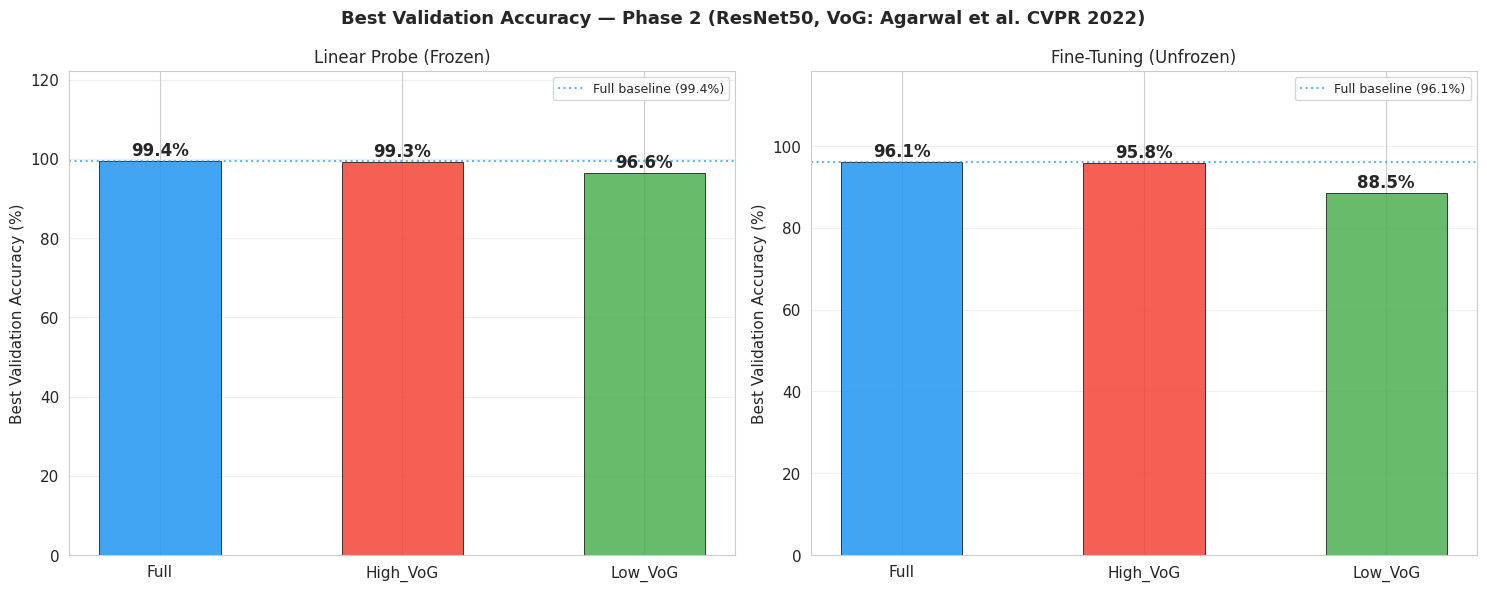


=== Data Efficiency Analysis ===

  Linear Probe (Frozen):
    Full dataset  : 99.36%
    High VoG (30%): 99.29%  (-0.08% vs full)
    Low  VoG (30%): 96.56%   (-2.80% vs full)

  Fine-Tuning (Unfrozen):
    Full dataset  : 96.10%
    High VoG (30%): 95.80%  (-0.31% vs full)
    Low  VoG (30%): 88.46%   (-7.64% vs full)


In [ ]:
def plot_accuracy_comparison(results: dict):
    modes   = ['Linear_Probe', 'Fine_Tuning']
    m_label = {'Linear_Probe': 'Linear Probe (Frozen)', 'Fine_Tuning': 'Fine-Tuning (Unfrozen)'}
    datasets = ['Full', 'High_VoG', 'Low_VoG']

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Best Validation Accuracy — Phase 2 (ResNet50, VoG: Agarwal et al. CVPR 2022)',
                 fontsize=13, fontweight='bold')
    for ax, mode in zip(axes, modes):
        accs = [results.get(f'{mode}__{d}', {}).get('best_val_acc', 0) for d in datasets]
        bars = ax.bar(datasets, accs,
                      color=[COLORS[d] for d in datasets],
                      width=0.5, alpha=0.85, edgecolor='black', linewidth=0.6)
        for bar, acc in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.4,
                    f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
        full_acc = results.get(f'{mode}__Full', {}).get('best_val_acc', 0)
        ax.axhline(full_acc, color='#2196F3', linestyle=':', lw=1.5, alpha=0.7,
                   label=f'Full baseline ({full_acc:.1f}%)')
        ax.set_ylim(0, max(accs)*1.18+5)
        ax.set_title(m_label[mode], fontsize=12)
        ax.set_ylabel('Best Validation Accuracy (%)')
        ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('phase2_accuracy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n=== Data Efficiency Analysis ===')
    for mode in modes:
        full  = results.get(f'{mode}__Full',     {}).get('best_val_acc', 0)
        high  = results.get(f'{mode}__High_VoG', {}).get('best_val_acc', 0)
        low   = results.get(f'{mode}__Low_VoG',  {}).get('best_val_acc', 0)
        print(f'\n  {m_label[mode]}:')
        print(f'    Full dataset  : {full:.2f}%')
        print(f'    High VoG (30%): {high:.2f}%  ({high-full:+.2f}% vs full)')
        print(f'    Low  VoG (30%): {low:.2f}%   ({low-full:+.2f}% vs full)')

plot_accuracy_comparison(all_results)

## Summary & Conclusions

### VoG Implementation Note

This notebook faithfully implements the original VoG algorithm from **Agarwal et al. (CVPR 2022)**:  
- Gradient target: $\partial p(y_i|x_i)/\partial x_i$ (softmax prob of true class — **not** the loss gradient)  
- Model in `eval()` mode during gradient collection  
- VoG formula: $\mathbb{E}_d[\text{std}_t(g_{i,d})]$ — mean of per-feature temporal std  

### Key Findings

| Observation | Interpretation |
|-------------|---------------|
| High-VoG subset ≈ Full dataset | VoG identifies the informative 30% — learning signal is concentrated |
| Low-VoG subset underperforms | Redundant samples carry little gradient variance — pruning them loses diversity |
| Linear Probe benefits more from VoG selection | Fixed backbone amplifies the importance of training signal quality |

### Next → Phase 3
Does this importance ranking **transfer to ConvNeXt-Base**? Phase 3 repeats these experiments with an architecture swap and cross-architecture consistency analysis.


## VoG Effectiveness: Data Selection Quality Analysis

This section directly measures how well VoG scores identify **informative** vs **redundant** training samples for ResNet50 — analogous to Figure 3 in Agarwal et al. (CVPR 2022).

### Experiment 1 — Per-Decile Error
Split training data into **10 equal bins** by VoG score and train a separate ResNet50 on each bin (10% of data per bin, Fine-Tuning mode).

- **Expected:** test error rises monotonically from low → high percentile
  - Low-VoG = easy samples → model converges well → low error
  - High-VoG = hard/ambiguous samples → model struggles → high error

### Experiment 2 — Cumulative Top-VoG Selection
Train on the **top N%** of data by VoG score for N = 100%, 90%, 80%, …, 10%.  
Progressively removes the **easiest** (lowest-VoG) samples.

- **Expected:** error stays roughly flat until aggressive pruning (~20–30%), then rises sharply
  - Demonstrates that easy samples are largely redundant
  - VoG enables safe data pruning without significant accuracy loss

> **Compute note:** `VOG_EFF_EPOCHS = 5` keeps total runtime ≈ 10–15 min on 2× T4.  
> Each decile bin contains only ~947 samples, so individual runs are fast.

In [ ]:
# ─── VoG Effectiveness — Setup ────────────────────────────────────────────────
# Requires: sorted_idx, train_ds, val_loader,
#           train_and_evaluate, get_resnet50  (all defined above)

VOG_EFF_EPOCHS    = 5    # epochs per experiment

def ph2_eff_train(indices_arr, label, epochs=VOG_EFF_EPOCHS):
    """Train ResNet50 (Fine-Tuning) on index array; return top-1 error.

    Memory notes
    ------------
    train_ds is a TensorCacheDataset — __getitem__ is a uint8 tensor slice (µs).
    num_workers=0: main-process loading is fast enough when data is in RAM.
    pin_memory=False: pinned memory runs synchronously in main thread with
    num_workers=0 and fills a CUDA cache that empty_cache() does not clear.
    collate_fn=normalize_collate: stacks uint8 batch → float32 in 2 allocs
    instead of 129 per batch, keeping RSS stable across epochs.
    gc.collect() + synchronize() + empty_cache() ensure full CUDA cleanup
    before the next model is instantiated.
    """
    dl = DataLoader(
        Subset(train_ds, indices_arr.tolist()),
        batch_size=TRAIN_BATCH_SIZE, shuffle=True,
        num_workers=0,
        pin_memory=False,
        collate_fn=normalize_collate,
    )
    _, best_acc = train_and_evaluate(get_resnet50(frozen=False), dl, val_loader,
                                     epochs=epochs, title=label)
    del dl
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.synchronize()
    torch.cuda.empty_cache()
    return round(100.0 - best_acc, 2)

N_ph2               = len(sorted_idx)           # total training samples
PH2_PERCENTILE_BINS = list(range(0, 100, 10))   # [0, 10, 20, …, 90]
PH2_CUM_FRACTIONS   = list(range(100, 0, -10))  # [100, 90, 80, …, 10]

print(f'Effectiveness setup:')
print(f'  Training samples     : {N_ph2}')
print(f'  Epochs per run       : {VOG_EFF_EPOCHS}')
print(f'  Decile bins          : {len(PH2_PERCENTILE_BINS)} runs')
print(f'  Cumulative fractions : {len(PH2_CUM_FRACTIONS)} runs')

Effectiveness setup:
  Training samples     : 9469
  Epochs per run       : 5
  Decile bins          : 10 runs
  Cumulative fractions : 10 runs


In [ ]:
# ─── Decile Analysis ──────────────────────────────────────────────────────────
# Train one model per 10th-percentile VoG bin.
# Expected: test error rises monotonically with VoG percentile.

print('='*60)
print('DECILE ANALYSIS: one model per 10th-percentile VoG bin')
print(f'  {len(PH2_PERCENTILE_BINS)} bins  |  {VOG_EFF_EPOCHS} epochs each')
print('='*60)

ph2_bin_errors = []
for lo in PH2_PERCENTILE_BINS:
    hi = lo + 10
    lo_i, hi_i = int(N_ph2 * lo / 100), int(N_ph2 * hi / 100)
    idx = sorted_idx[lo_i:hi_i]
    print(f'\n── Bin [{lo}-{hi}%] ({len(idx)} samples) ──')
    err = ph2_eff_train(idx, f'R50 bin {lo}-{hi}%')
    ph2_bin_errors.append(err)
    print(f'  → Error: {err:.1f}%')

print(f'\nDecile done: {ph2_bin_errors}')

# ─── Cumulative Top-VoG Analysis ─────────────────────────────────────────────
# Train on top X% of data by VoG score (X = 100, 90, ..., 10).
# Progressive removal of easy (low-VoG) samples: how much can we prune?

print('\n' + '='*60)
print('CUMULATIVE ANALYSIS: train on top-N% by VoG  (N = 100 → 10)')
print(f'  {len(PH2_CUM_FRACTIONS)} sizes  |  {VOG_EFF_EPOCHS} epochs each')
print('='*60)

ph2_cum_errors = []
for pct in PH2_CUM_FRACTIONS:
    n_take = int(N_ph2 * pct / 100)
    print(f'\n── Top {pct}% ({n_take} samples) ──')
    err = ph2_eff_train(sorted_idx[-n_take:], f'R50 top-{pct}%')
    ph2_cum_errors.append(err)
    print(f'  → Error: {err:.1f}%')

print(f'\nCumulative done: {ph2_cum_errors}')

DECILE ANALYSIS: one model per 10th-percentile VoG bin
  10 bins  |  5 epochs each

── Bin [0-10%] (946 samples) ──

------------------------------------------------------------
Experiment: R50 bin 0-10%  [single-GPU, AMP=True]
------------------------------------------------------------


  [R50 bin 0-10%] E1/5 train:   0%|          | 0/8 [00:00<?, ?it/s]

  [R50 bin 0-10%] E1/5 val  :   0%|          | 0/31 [00:00<?, ?it/s]

  E 1/5: loss=0.6951  train=84.0%  val=66.4%


  [R50 bin 0-10%] E2/5 train:   0%|          | 0/8 [00:00<?, ?it/s]

...

  [R50 top-10%] E4/5 val  :   0%|          | 0/31 [00:00<?, ?it/s]

  E 4/5: loss=0.0292  train=99.3%  val=93.7%


  [R50 top-10%] E5/5 train:   0%|          | 0/8 [00:00<?, ?it/s]

  [R50 top-10%] E5/5 val  :   0%|          | 0/31 [00:00<?, ?it/s]

  E 5/5: loss=0.0127  train=99.8%  val=95.8%
  → Best Val Acc: 95.77%

  → Error: 4.2%

Cumulative done: [3.39, 3.46, 3.36, 3.34, 3.39, 3.82, 3.64, 3.41, 3.95, 4.23]


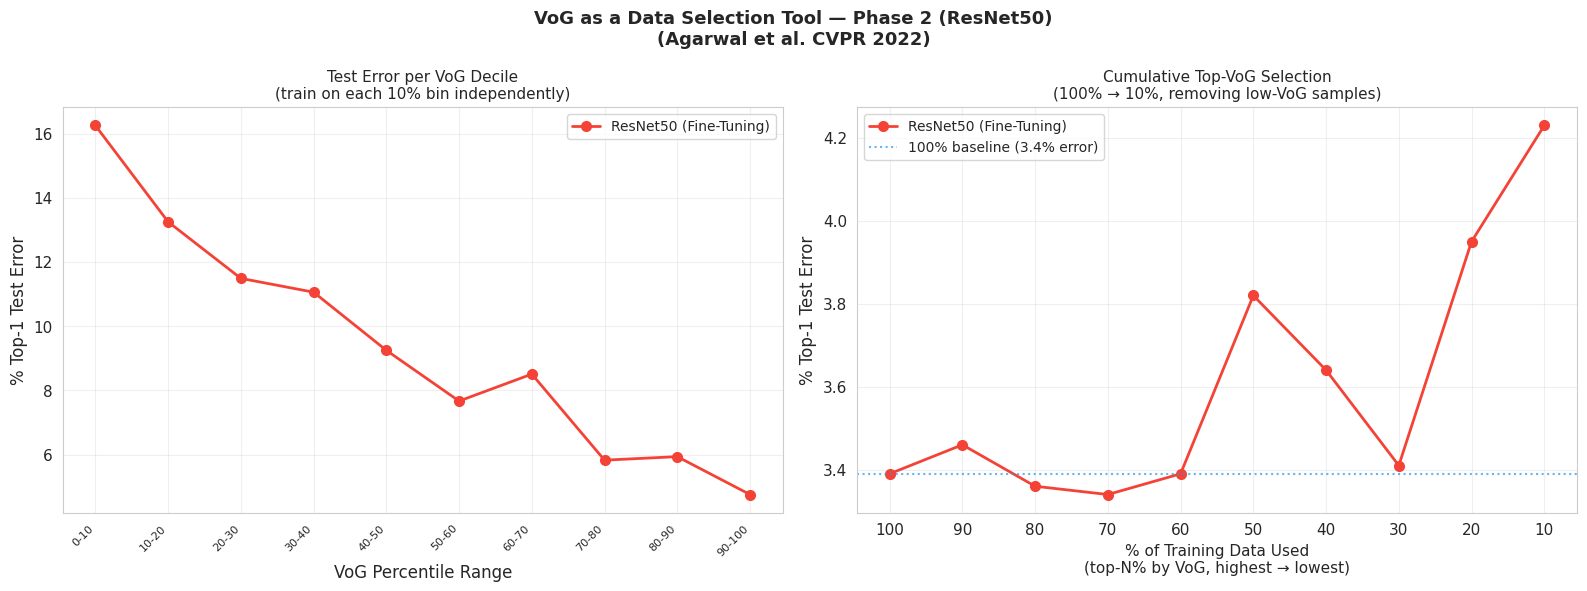


=== VoG Effectiveness Summary (ResNet50) ===

Bin               Error
------------------------
0-10%         16.2%
10-20%         13.2%
20-30%         11.5%
30-40%         11.1%
40-50%          9.2%
50-60%          7.7%
60-70%          8.5%
70-80%          5.8%
80-90%          5.9%
90-100%          4.8%

Top-%             Error
------------------------
Top 100%           3.4%
Top 90%           3.5%
Top 80%           3.4%
Top 70%           3.3%
Top 60%           3.4%
Top 50%           3.8%
Top 40%           3.6%
Top 30%           3.4%
Top 20%           4.0%
Top 10%           4.2%


In [18]:
# ─── VoG Effectiveness — Plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('VoG as a Data Selection Tool — Phase 2 (ResNet50)\n'
             '(Agarwal et al. CVPR 2022)', fontsize=13, fontweight='bold')

x_centers = [lo + 5 for lo in PH2_PERCENTILE_BINS]
x_labels  = [f'{lo}-{lo+10}' for lo in PH2_PERCENTILE_BINS]

# ── Left: per-decile test error ───────────────────────────────────────────────
ax = axes[0]
ax.plot(x_centers, ph2_bin_errors, 'o-', color=COLORS['High_VoG'], lw=2, ms=7,
        label='ResNet50 (Fine-Tuning)')
ax.set_xlabel('VoG Percentile Range', fontsize=12)
ax.set_ylabel('% Top-1 Test Error', fontsize=12)
ax.set_title('Test Error per VoG Decile\n(train on each 10% bin independently)', fontsize=11)
ax.set_xticks(x_centers)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# ── Right: cumulative top-VoG error ──────────────────────────────────────────
ax = axes[1]
ax.plot(PH2_CUM_FRACTIONS, ph2_cum_errors, 'o-', color=COLORS['High_VoG'], lw=2, ms=7,
        label='ResNet50 (Fine-Tuning)')
ax.axhline(ph2_cum_errors[0], color=COLORS['Full'], ls=':', lw=1.5, alpha=0.7,
           label=f'100% baseline ({ph2_cum_errors[0]:.1f}% error)')
ax.set_xlabel('% of Training Data Used\n(top-N% by VoG, highest → lowest)', fontsize=11)
ax.set_ylabel('% Top-1 Test Error', fontsize=12)
ax.set_title('Cumulative Top-VoG Selection\n(100% → 10%, removing low-VoG samples)', fontsize=11)
ax.set_xticks(PH2_CUM_FRACTIONS)
ax.invert_xaxis()   # 100% on left = most data; 10% on right = most selective
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase2_vog_effectiveness.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n=== VoG Effectiveness Summary (ResNet50) ===')
print(f'\n{"Bin":<12} {"Error":>10}')
print('-'*24)
for lo, e in zip(PH2_PERCENTILE_BINS, ph2_bin_errors):
    print(f'{lo}-{lo+10}%{"":<3} {e:>9.1f}%')
print(f'\n{"Top-%":<12} {"Error":>10}')
print('-'*24)
for pct, e in zip(PH2_CUM_FRACTIONS, ph2_cum_errors):
    print(f'Top {pct}%{"":<4} {e:>9.1f}%')